6장 컴퓨터 비전

In [ ]:
# 예제 6.1 이미지 분류 CNN 모델(CIFAR-10)

#셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense
from tensorflow.keras.layers import Flatten, Dropout
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt

# 데이터셋 준비
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape, y_train.shape)   # 학습 데이터 shape 확인
print(x_test.shape, y_test.shape)   # 테스트 데이터 shape 확인

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


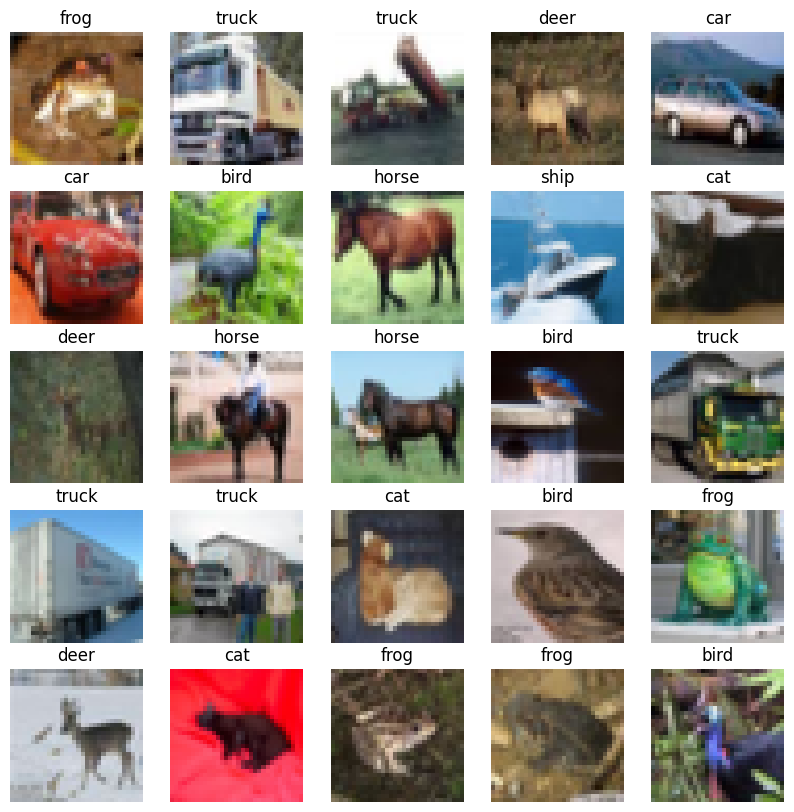

In [ ]:
# 학습 데이터 시각화
class_names = ['plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i].item()])
    plt.axis('off')

plt.show()

In [ ]:
# 데이터 정규화
x_train, x_test = x_train / 255., x_test / 255.

In [ ]:
# 특징 추출 신경망
inputs = Input(shape=(32, 32, 3))
x = Conv2D(32, kernel_size=3, padding='same', activation='relu')(inputs)
x = Conv2D(32, kernel_size=3, padding='same', activation='relu')(x)
x = MaxPooling2D(pool_size=2)(x)

x = Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
x = Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
x = MaxPooling2D(pool_size=2)(x)

x = Conv2D(128, kernel_size=3, padding='same', activation='relu')(x)
x = MaxPooling2D(pool_size=2)(x)

# 분류 신경망
x = Flatten()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(10, activation='softmax')(x)

# 모델 생성
model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# 모델 학습
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3)

history = model.fit(x_train, y_train, batch_size=32, epochs=50,
                    validation_split=0.2, verbose=0,
                    callbacks=early_stopping)

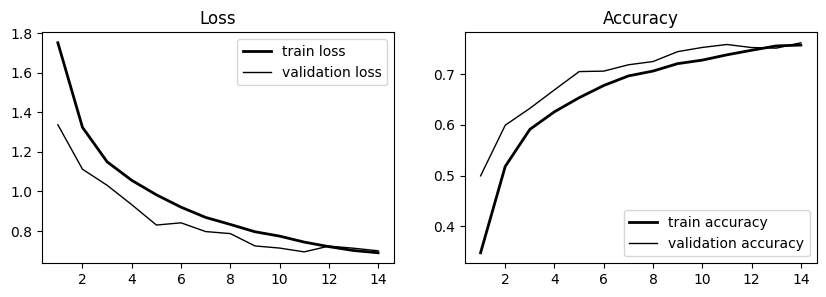

In [ ]:
# 학습 결과 시각화
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

axs[0].plot(range(1, len(history.history['loss']) + 1),
            history.history['loss'], label='train loss',
            color='black', linewidth=2)
axs[0].plot(range(1, len(history.history['val_loss']) + 1),
            history.history['val_loss'], label='validation loss',
            color='black', linewidth=1)
axs[0].set_title('Loss')
axs[0].legend(loc='best')

axs[1].plot(range(1, len(history.history['accuracy']) + 1),
            history.history['accuracy'], label='train accuracy',
            color='black', linewidth=2)
axs[1].plot(range(1, len(history.history['val_accuracy']) + 1),
            history.history['val_accuracy'], label='validation accuracy',
            color='black', linewidth=1)
axs[1].set_title('Accuracy')
axs[1].legend(loc='best')

plt.show()

In [ ]:
# 모델 평가
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7529 - loss: 0.7242


[0.7299676537513733, 0.7501999735832214]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 851ms/step


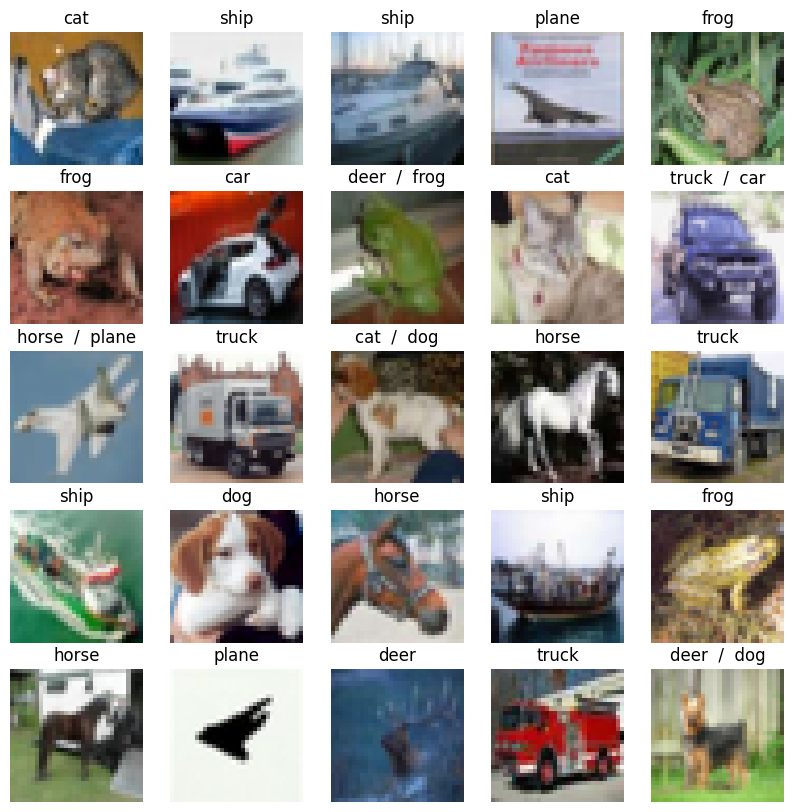

In [ ]:
# 모델 예측 결과 시각화
x = x_test[:25]
y_pred = np.argmax(model.predict(x), axis=1)

plt.figure(figsize=(10 ,10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_test[i])
    if y_pred[i] != y_test[i]:
        plt.title(class_names[y_pred[i].item()] + '  /  '
                 + class_names[y_test[i].item()])
    else:
        plt.title(class_names[y_pred[i].item()])
    plt.axis('off')

plt.show()

In [ ]:
# 예제 6.2 VGG16 전이 학습(Cats_and_Dogs)

# 셋업
import tensorflow as tf
from tensorflow.keras import Sequential, Model, Input
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.utils import image_dataset_from_directory
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

# 데이터셋 다운로드
url = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
path_zip = tf.keras.utils.get_file('cats_and_dogs.zip', origin=url, extract=True)
path = os.path.join(os.path.dirname(path_zip), 'cats_and_dogs_filtered')

train_dir = os.path.join(path, 'train')   # 학습 데이터 경로 지정
valid_dir = os.path.join(path, 'validation')   # 검증 데이터 경로 지정

print(os.listdir(train_dir))   # 하위 폴더 확인
print(os.listdir(valid_dir))

68606236/68606236 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
['cats', 'dogs']
['cats', 'dogs']


In [ ]:
# 데이터 준비
train_ds = image_dataset_from_directory(train_dir, shuffle=True,
                                        batch_size=32,
                                        image_size=(160, 160))
valid_ds = image_dataset_from_directory(valid_dir, shuffle=True,
                                        batch_size=32,
                                        image_size=(160, 160))

print(len(train_ds))   # 학습 데이터 크기 확인
print(len(valid_ds))   # 검증 데이터 크기 확인

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
63
32


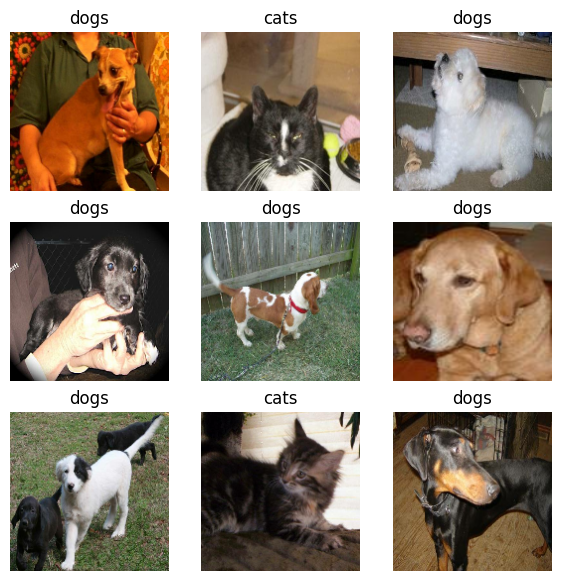

In [ ]:
# 학습 데이터 시각화
class_name = train_ds.class_names   # 클래스명(cats, dogs)

for image, label in train_ds.take(1):   # 레이블(0, 1)
    plt.figure(figsize=(7, 7))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(image[i] / 255)
        plt.title(class_name[label[i]])
        plt.axis("off")

    plt.show()

In [ ]:
# 검증/테스트 데이터 분할
valid_batch = len(valid_ds)
valid_ds = valid_ds.skip(valid_batch // 2)   # 분할 바율 0.5
test_ds = valid_ds.take(valid_batch // 2)

print(f"{len(valid_ds)}")   # 검증 데이터 확인
print(f"{len(test_ds)}")   # 테스트 데이터 확인

16
16


In [ ]:
# 데이터 증강
image_augment = Sequential([
    RandomFlip('horizontal'),   # 수평 뒤집기
    RandomRotation(0.2),   # 회전
    RandomZoom(0.3)   # 확대
])

In [ ]:
# VGG16 베이스 모델 생성
base_model = VGG16(include_top=False,   # 분류 신경망 포함하지 않음
                   weights='imagenet',   # ImageNet으로 학습한 가중치
                   input_shape=(160, 160, 3))
base_model.trainable = False   # 베이스 모델 동결

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# 모델 생성
inputs = Input(shape=(160, 160, 3))
x = image_augment(inputs)   # 데이터 증강
x = preprocess_input(x)   # 정규화
x = base_model(x)    # VGG16 베이스 모델
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)   # 은닉층 뉴런 128개
x = Dropout(0.5)(x)   # 드롭아웃 비율 0.5
outputs = Dense(1, activation='sigmoid')(x)   # 출력층 뉴런 1개

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# 모델 학습
history = model.fit(train_ds, epochs=10, validation_data=valid_ds)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 152ms/step - accuracy: 0.7310 - loss: 1.7853 - val_accuracy: 0.9303 - val_loss: 0.2670
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.8700 - loss: 0.5246 - val_accuracy: 0.9693 - val_loss: 0.1186
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.8987 - loss: 0.3076 - val_accuracy: 0.9631 - val_loss: 0.1082
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.9034 - loss: 0.2499 - val_accuracy: 0.9508 - val_loss: 0.1241
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - accuracy: 0.9016 - loss: 0.2301 - val_accuracy: 0.9672 - val_loss: 0.0928
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.9245 - loss: 0.1938 - val_accuracy: 0.9590 - val_loss: 0.0935
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - accuracy: 0.9215 - loss: 0.1783 - val_accuracy: 0.9611 - val_loss: 0.1029
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.9147 - loss: 0.2172 - val_accura

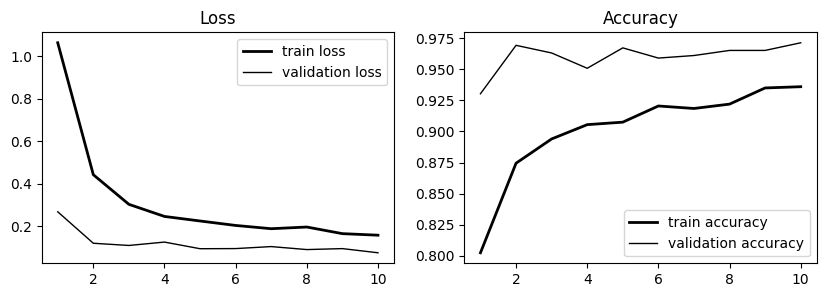

In [ ]:
# 학습 결과 시각화
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

axs[0].plot(range(1, len(history.history['loss']) + 1),
            history.history['loss'], label='train loss',
            color='black', linewidth=2)
axs[0].plot(range(1, len(history.history['val_loss']) + 1),
            history.history['val_loss'], label='validation loss',
            color='black', linewidth=1)
axs[0].set_title('Loss')
axs[0].legend(loc='best')

axs[1].plot(range(1, len(history.history['accuracy']) + 1),
            history.history['accuracy'], label='train accuracy',
            color='black', linewidth=2)
axs[1].plot(range(1, len(history.history['val_accuracy']) + 1),
            history.history['val_accuracy'], label='validation accuracy',
            color='black', linewidth=1)
axs[1].set_title('Accuracy')
axs[1].legend(loc='best')

plt.show()

In [ ]:
# 모델 평가
model.evaluate(test_ds)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.9626 - loss: 0.0851


[0.08665549010038376, 0.9672130942344666]

Prediction: 
 [0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 1 0]
Label: 
 [1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 1 0]


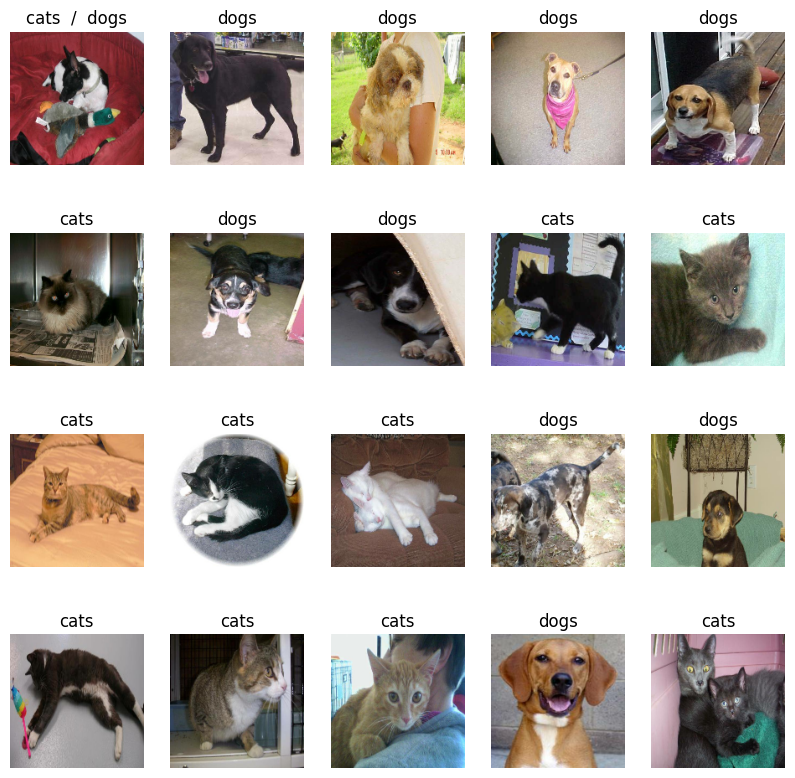

In [ ]:
# 모델 예측 결과 시각화
image, label = next(iter(test_ds))        # 이터레이터 사용하여 배치 가져옴
prediction = model.predict_on_batch(image).reshape(-1)   # 배치 단위로 예측
predict = (prediction >= 0.5).astype(int)   # 임계치 0.5

print(f"Prediction: \n {predict}")
print(f"Label: \n {label}")

plt.figure(figsize=(10, 10))

for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(image[i] / 255)
    if predict[i] != label[i]:
        plt.title(class_name[predict[i]] + '  /  '
                  + class_name[label[i]])
    else:
        plt.title(class_name[predict[i]])
    plt.axis('off')
plt.show()